## License

This notebook is a conversion of a Sentinel Hub evalscript and is licensed under
**CC-BY-SA-4.0**.  

Original evalscript: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/vegetation_condition_index/  
Source: Sentinel Hub Custom Scripts (CC-BY-SA-4.0)  
Conversion: Development Seed (openEO-UDP project)  


# Vegetation Condition Index

This notebook demonstrates how to calculate the Vegetation Condition Index (VCI) from Sentinel‑2 Normalized Difference Vegetation Index (NDVI) time series using openEO. The script evaluates vegetation status on an **observed date**, defined as the newest available Sentinel‑2 acquisition within the requested temporal extent. It then identifies **historical dates** within a 5‑day window around this observed date and computes the minimum and maximum NDVI over these historical acquisitions, which are subsequently compared to the NDVI on the observed date to derive VCI.

## Pre‑processing Step to Create Cloud-Free Images

The Evalscript includes a pre‑processing step that removes cloudy pixels from Sentinel‑2 scenes acquired for the selected dates. In the reference Evalscript, cloud removal is based on a dedicated cloud mask band (e.g. `CLP`). However, openEO backends such as CDSE do not provide this band directly. As a workaround, we use the Scene Classification Layer (`SCL`) available in the Sentinel‑2 data on CDSE. The following SCL values will be removed to generate a cloud mask and filter out cloudy pixels (reference: [Cloudless Mosaic Script](https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/cloudless_mosaic/)):
- 0 - No data
- 1 - Saturated / defective
- 3 - Cloud shadows
- 8 - Clouds medium probability
- 9 - Clouds high probability
- 10 - Cirrus
- 11 - Snow/ice

## Calculation of Vegetation Condition Index (VCI)

VCI is calculated on cloud-free images as:

\begin{equation*}
\text{VCI} = \frac{\text{NDVI}_{\text{observed}} - \text{NDVI}_{\text{hist,min}}}{\text{NDVI}_{\text{hist,max}} - \text{NDVI}_{\text{hist,min}}}
\end{equation*}

## Overview

In this notebook, we will:
1. Connect to the CDSE openEO backend (https://openeo.dataspace.copernicus.eu/)
2. Define an area of interest containing terrestrial land
3. Create cloud‑free scenes for the selected dates, using SCL band and Braaten-Cohen-Yang cloud detector
4. Calculate NDVI from the cloud‑free scenes
5. Define the observed and historical dates
    - The observed date is the newest available Sentinel‑2 acquisition within the requested time interval
    - Historical dates are all other acquisition dates that fall within a 5‑day window around this observed date
6. Calculate the Vegetation Condition Index (VCI)


## Import Required Libraries

We begin by importing the necessary Python libraries for data processing and visualization.

In [ ]:
import rioxarray
import openeo
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from openeo.processes import if_, and_, neq, absolute


## Connect to Copernicus (CDSE) backend

Connect to Copernicus (CDSE) openEO backend and authenticate using OpenID Connect.

In [2]:
connection = openeo.connect(
    url="https://openeo.dataspace.copernicus.eu/"
).authenticate_oidc()

Authenticated using refresh token.


## Define Area of Interest

Define the spatial extent for our analysis. The spatial extent below corresponds to Dodge City, Kansas, United States

In [ ]:
spatial_extent = {"west" : -100.80, "south" : 37.94, "east" : -100.61, "north" : 38.03}

## Load Sentinel-2 Product

In [ ]:
# The initial time range to evaluate data availability and their acquisition dates
selected_date = "2020-05-20"

# Convert to datetime objects
dt_format = "%Y-%m-%d"
sel_date = datetime.strptime(selected_date, dt_format)

# 5 days before and after
dt_minus_5 = sel_date - timedelta(days=5)
dt_plus_5 = sel_date + timedelta(days=5)

# Turn them to string
dt_minus_5 = str(dt_minus_5.date())
dt_plus_5 = str(dt_plus_5.date())

s2cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent=spatial_extent,
    temporal_extent=[dt_minus_5, dt_plus_5],
    bands=["B03", "B04", "B08", "SCL"]
)

In [5]:
# openEO and_() is binary; chained here for: SCL not in {0,1,3,8,9,10,11}
def remove_cloud(scl_band):
    return and_(
        neq(scl_band, 3),
        and_(
            neq(scl_band, 9),
            and_(
                neq(scl_band, 8),
                and_(
                    neq(scl_band, 10),
                    and_(
                        neq(scl_band, 11),
                        and_(
                            neq(scl_band, 1),
                            neq(scl_band, 0)
                        )
                    )
                )
            )
        )
    )

In [ ]:
def ndvi_calculation(data):
    B03, B04, B08, SCL = (
        data[0],
        data[1],
        data[2],
        data[3]
    )

    # Scale CDSE integer data to reflectance [0, 1]
    B03 = B03 / 10000
    B04 = B04 / 10000
    B08 = B08 / 10000

    # Algorithm to create clear, cloud-less images
    is_not_cloud = remove_cloud(SCL)

    # Cloud-free bands
    B04_cf = if_(is_not_cloud, B04, None)
    B08_cf = if_(is_not_cloud, B08, None)

    denom = B08_cf + B04_cf

    ndvi = if_(absolute(denom) > 0, (B08_cf - B04_cf) / denom, None)

    return ndvi

In [ ]:
ndvi = s2cube.apply_dimension(
    dimension="bands",
    process=ndvi_calculation
)

# NDVI min and max from cloud-free image
ndvi_min = ndvi.reduce_dimension(dimension="t", reducer="min")
ndvi_max = ndvi.reduce_dimension(dimension="t", reducer="max")

# NDVI calculated from cloud-free image on the observed date
ndvi_obs = ndvi.reduce_dimension(dimension="t", reducer="last")

In [ ]:
# Calculate denominator for VCI = ndvi_max - ndvi_min
max_min = ndvi_max.merge_cubes(
    ndvi_min,
    overlap_resolver="subtract"
)

# Calculate the numerator for VCI = ndvi_obs - ndvi_min
obs_min = ndvi_obs.merge_cubes(
    ndvi_min,
    overlap_resolver="subtract"
)

# Calcualte VCI = (ndvi_obs - ndvi_min) / (ndvi_max - ndvi_min)
vci = obs_min.merge_cubes(
    max_min,
    overlap_resolver="divide"
)

In [ ]:
vci = vci.save_result("GTiff")
vci.download("vci.tif")

# test_cloud_mask = ndvi_obs.save_result("GTiff")
# test_cloud_mask.download("test_cloud_mask_22May.tif")

In [10]:
# Save the selected dates with available satellite imagery data in a metadata
time_labels = ndvi.dimension_labels("t").execute()

In [11]:
# The format from dimension_labels() process
dt_format = "%a, %d %b %Y %H:%M:%S %Z" 

# Convert to datetime objects
dt_list = [datetime.strptime(d, dt_format) for d in time_labels]

# Find the observed date
observed_date = max(dt_list)

# Storing observed date and historical dates in a metadata dict for transparency
metadata = {
    "observed_date" : [str(observed_date.date())],
    "historical_date" : [str(date.date()) for date in dt_list if date != observed_date]
}

metadata

{'observed_date': ['2020-05-22'],
 'historical_date': ['2020-05-15', '2020-05-17', '2020-05-20']}

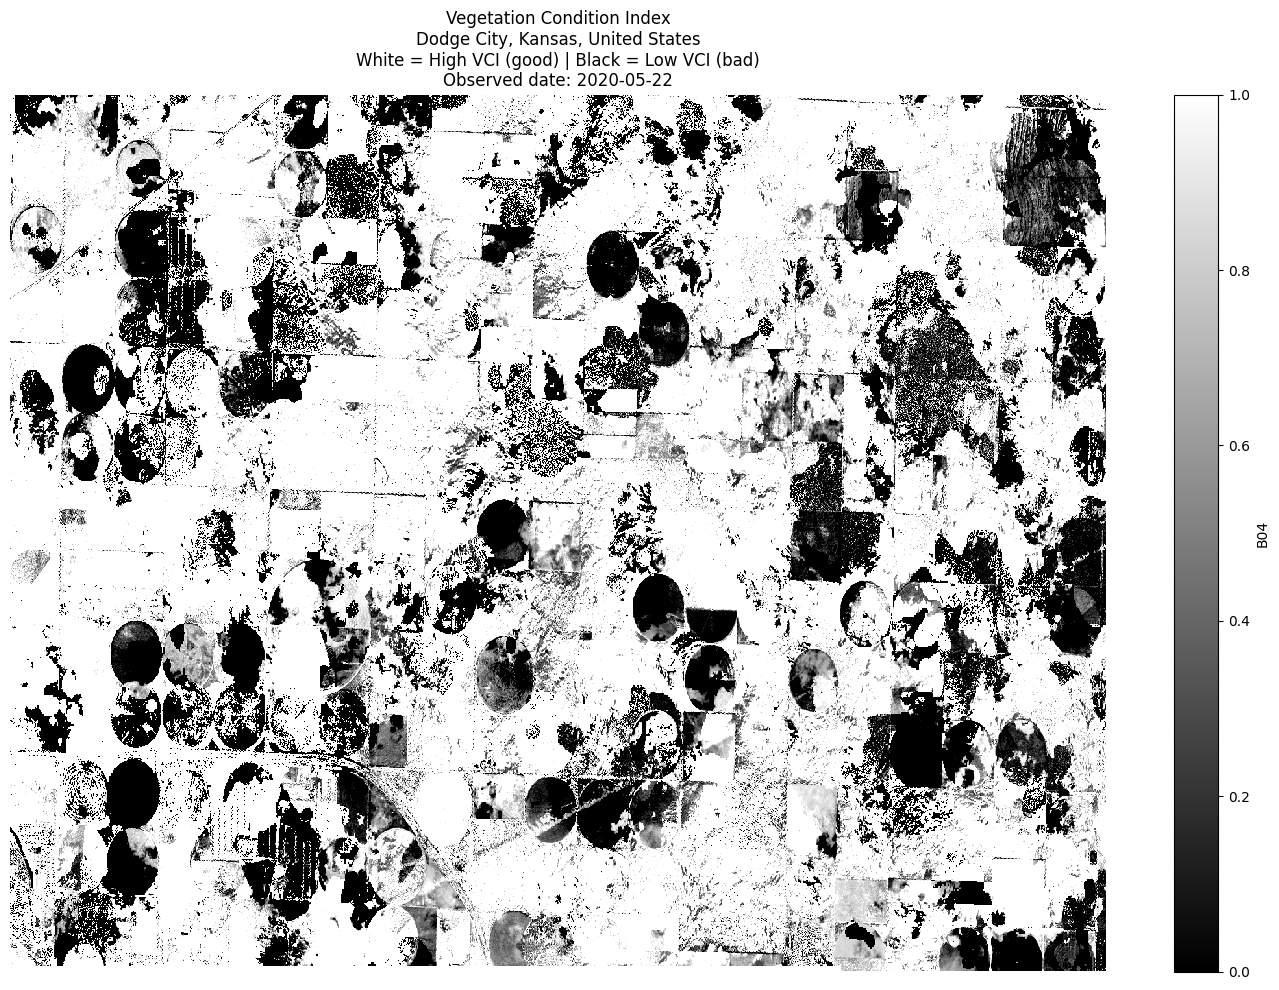

In [12]:
ds = rioxarray.open_rasterio("vci.tif")

vci = ds.squeeze() # 2-D array

fig, ax = plt.subplots(figsize=(14, 10), dpi=100)
vci.plot.imshow(
    cmap="gray",  # black (low) -> white (high)
    vmin=0,
    vmax=1,
    ax=ax
)
ax.set_title(
    "Vegetation Condition Index\n"
    "Dodge City, Kansas, United States\n"
    "White = High VCI (good) | Black = Low VCI (bad)\n"
    f"Observed date: {metadata["observed_date"][0]}",
    fontsize=12,
)
ax.axis("off")
plt.tight_layout()
plt.show()
